<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Neural_Network_Using_Tensorflow_and_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tensorflow is a package developed by Google while Keras is a framework used with tensorflow to make it easy for layer handling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense , Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError,BinaryCrossentropy
from tensorflow.keras.activations import sigmoid


Neural Network Without Activation - Linear / Regression Model

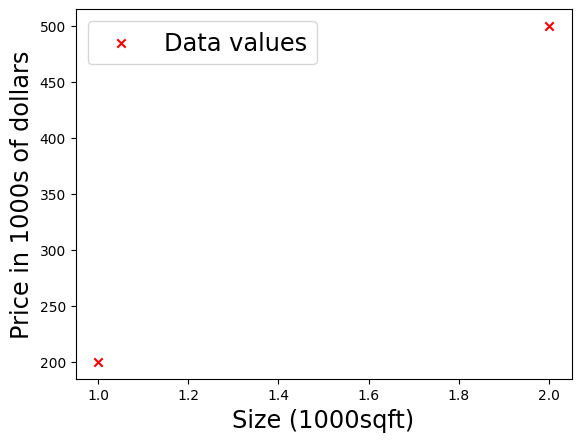

In [2]:
X_train = np.array([[1.0],[2.0]],dtype = np.float32) # Size of house in 1000 sq feet
Y_train = np.array([[200.0],[500.0]],dtype = np.float32) # Price of house in thousand dollar

fig,ax = plt.subplots(1,1)
ax.scatter(X_train,Y_train,marker='x',c='r',label="Data values")
ax.legend(fontsize='xx-large')
ax.set_ylabel('Price in 1000s of dollars',fontsize='xx-large')
ax.set_xlabel('Size (1000sqft)',fontsize = 'xx-large')
plt.show()

In [3]:
# Defining a neuron with one layer and activation as linear

linear_layer = tf.keras.layers.Dense(units=1,activation='linear',)

#let see the weights - currently no weights will be there
linear_layer.get_weights()

[]

In [4]:
# We need to reshape the X_train into 2D arr because of tensorflow

a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

w,b = linear_layer.get_weights()
print(f"w : {w} and b : {b}")

tf.Tensor([[0.22678769]], shape=(1, 1), dtype=float32)
w : [[0.22678769]] and b : [0.]


In [6]:
# Lets set the weights to some values

set_w = np.array([[200]])
set_b = np.array([100])

#set_weights() takes a list of numpy arrays

linear_layer.set_weights([set_w,set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [7]:
#Lets verify whether the layer has taken the weights or not

a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)
alin = np.dot(set_w,X_train[0].reshape(1,1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


In [8]:
# So they are giving same results lets use it to predict on the trainign data

predict_tf = linear_layer(X_train)
predict_np = np.dot(X_train,set_w) + set_b

print(predict_tf)
print(predict_np)

tf.Tensor(
[[300.]
 [500.]], shape=(2, 1), dtype=float32)
[[300.]
 [500.]]


Neurons with Sigmoid Activation

In [9]:
X_train = np.array([0.,1,2,3,4,5],dtype = np.float32).reshape(-1,1) # 2D Matrix
Y_train = np.array([0,0,0,1,1,1],dtype = np.float32).reshape(-1,1)

print(X_train)
print(Y_train)

[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]]
[[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]]


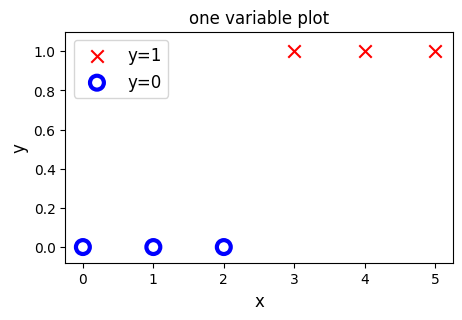

In [11]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.scatter(X_train[pos],Y_train[pos],marker='x',s=80,c='red',label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none',
              edgecolors="blue",lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

In [12]:
#Logistic Neuron
# This part will use Sequential model to create the models generally Tensorflow is used to create multi-layer models

model = Sequential(
    [
        tf.keras.layers.Dense(1,input_dim=1,activation='sigmoid',name = 'L1')
    ]
)

model.summary()
# Shows the layers and no of parameters of the model
# paramaters here is 2 (w,b) and units is 1

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape,b.shape)

[[1.1075927]] [0.]
(1, 1) (1,)


In [14]:
# Setting the parameters

set_w = np.array([[2]])
set_b = np.array([4.5])

logistic_layer.set_weights([set_w,set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([4.5], dtype=float32)]


In [17]:
def sigmo(z):
  return 1/(1+np.exp(-z))

In [19]:
# Lets verify the results

a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = sigmo(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[0.9890131]]
[[0.98901306]]
